# Multimodal Classification with SigLIP Embeddings

A 200-class fine-grained image classifier (bird species) built on pre-computed
SigLIP vision-language embeddings, plus an analysis of how the image and caption
representations relate. Working from 768-dimensional features for ~8.6K training
samples, this notebook:

1. Measures how well the image embeddings separate the 200 classes.
2. Tests image-to-caption retrieval (Recall@5) across the two modalities.
3. Clusters each modality and quantifies their agreement (Adjusted Rand Index).
4. Trains and tunes an MLP classifier and generates test-set predictions.

**Stack:** Python - NumPy - scikit-learn (MLPClassifier, KMeans, GridSearchCV) - SciPy - matplotlib

## The data

Pre-computed SigLIP embeddings for images and their captions (768-dim each),
alongside the raw 32x32 images, caption strings, and integer class labels. We
start by inspecting a single training example.

Image:


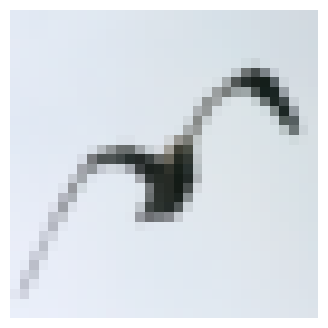

Caption:
the bird has beak and head proportional to its body with its whole body covered in black.


In [4]:
# Inspect a single training example: the raw 32x32 image and its caption.
import numpy as np
import matplotlib.pyplot as plt


images = np.load("images_train.npy")
captions = np.load("captions_train.npy", allow_pickle=True)

idx = 0  # change index to inspect different samples

print("Image:")
plt.figure(figsize=(4, 4))
plt.imshow(images[idx])
plt.axis("off")
plt.show()

print("Caption:")
print(captions[idx])

## 1. Feature quality: how well do the embeddings separate the classes?

Before modelling, we check whether the image embeddings are informative: are
samples of the same class closer together than samples of different classes?

- **Intra-class distance:** average Euclidean distance between same-class pairs.
- **Inter-class distance:** average Euclidean distance between different-class pairs.
- **Separation ratio = inter / intra** - a value above 1 means the embedding
  space already pulls classes apart, a good sign for a downstream classifier.

In [27]:
%%time
import numpy as np
from scipy.spatial.distance import pdist
def distance(a, b):
    """
    Computes and returns the Euclidean distance between two features a and b.
    """
    return np.sqrt(np.sum((a-b)**2))

# Load the image features and their class labels.
image_features_train = np.load("image_features_train.npy")
labels_train = np.load("labels_train.npy")

distances=pdist(image_features_train,metric='euclidean')
label_dists=pdist(labels_train.reshape(-1,1),metric='euclidean')
# Pairs with the same label are intra-class...
intra_mask=(label_dists==0)
# ...and pairs with different labels are inter-class.
inter_mask=(label_dists>0)

intra_class_distance=np.mean(distances[intra_mask])
inter_class_distance=np.mean(distances[inter_mask])

# Separation ratio > 1 means classes are, on average, farther apart than within.
separation_ratio=inter_class_distance/intra_class_distance
print(f"Separation ratio: {separation_ratio:.4f}")

Separation ratio: 1.1804
CPU times: user 10.5 s, sys: 899 ms, total: 11.4 s
Wall time: 10.5 s


## 2. Cross-modal retrieval: do images find their own captions?

Each image and its caption are encoded into comparable feature spaces. If the two
modalities are well aligned, an image's own caption should be one of its nearest
neighbours. For every image we take the 5 closest captions and check whether the
correct one (caption *i* for image *i*) is among them - i.e. **Recall@5**.

In [28]:
%%time

import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

# Load both the image and caption feature sets.
image_features_train = np.load("image_features_train.npy")
caption_features_train = np.load("caption_features_train.npy")

# Distance from every image to every caption.
dists=euclidean_distances(image_features_train,caption_features_train)
# For each image, take the indices of its 5 nearest captions.
top5= np.argsort(dists, axis=1)[:,:5]

corrects= np.arange(len(image_features_train)).reshape(-1, 1)
# The correct caption for image i is caption i; check if it is among the top 5.
matches = (top5==corrects)

# Recall@5: share of images whose correct caption is in the top 5.
success=np.any(matches, axis=1)
proportion=np.mean(success)

print("Proportion with correct caption in top 5:", proportion)

Proportion with correct caption in top 5: 0.0034714186530895625
CPU times: user 11.5 s, sys: 1.83 s, total: 13.4 s
Wall time: 5.06 s


## 3. Clustering: do the two modalities agree?

We cluster the image features and the caption features separately (KMeans, 200
clusters each), inspect the two most distant clusters in each modality to see what
they capture, and then measure how much the image and caption groupings agree
using the **Adjusted Rand Index (ARI)**.

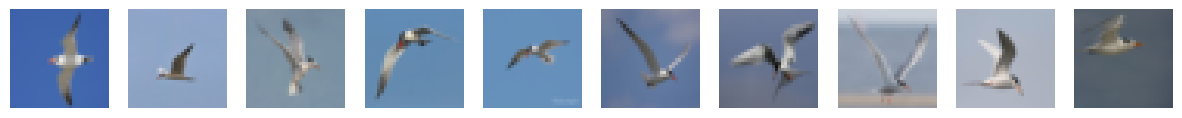

------------------------------------


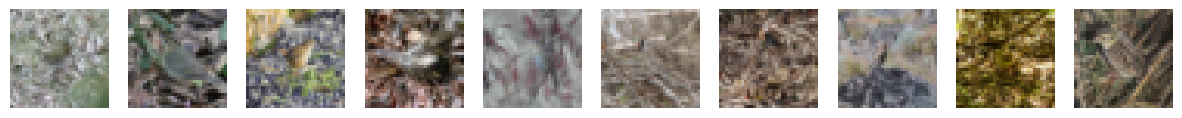

this bird has a mix of stripes/blotted black feathers on its back and wings, with a belly consisting of white, with a slight hint of grey.
a very small bird with a head that is relatively small to it's body, with a light brown beak and crown, with a pale yellow breast.
this small bird has a black crown, is brown around the eye except for a black streak under the eye, has a short, sharp beak, and has brown tarsi.
a really small bird wiith dark silver/gray back and wingbars with a more light gray area tuning up on his belly and breast.
the small, round, white and brown bird has thin, orange tarsus, a short, thick, pointed beak and a small head relative to its body.
------------------------------------
this is a yellow bird with a white wing, a yellow eyebrow and a white beak.
this is a brown bird with a white spotted belly and a yellow crown.
a brown bird with a speckled belly and an orange crown.
this bright yellow and black bird with a short beak and a bright yellow eyebrow has white o

In [29]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt


# Load the image and caption feature sets.
image_features_train = np.load("image_features_train.npy")
caption_features_train = np.load("caption_features_train.npy")

# Cluster each modality separately into 200 groups (fixed seed for reproducibility).
kmeans_image=KMeans(n_clusters=200,random_state=42)
kmeans_image.fit(image_features_train)
kmeans_caption=KMeans(n_clusters=200,random_state=42)
kmeans_caption.fit(caption_features_train)

# Cluster centroids for each modality.
center_image=kmeans_image.cluster_centers_
center_caption=kmeans_caption.cluster_centers_

# Pairwise distances between centroids.
center_distance_image=euclidean_distances(center_image)
center_distance_caption=euclidean_distances(center_caption)

# Identify the two most distant clusters in each modality.
cluster_a_image, cluster_b_image = np.unravel_index(np.argmax(center_distance_image), center_distance_image.shape)
cluster_a_caption,cluster_b_caption=np.unravel_index(np.argmax(center_distance_caption),center_distance_caption.shape)

# Load the raw images and captions to inspect those clusters.
images_train=np.load("images_train.npy")
captions_train=np.load("captions_train.npy",allow_pickle=True)

pic_in_cluster_a_image=images_train[kmeans_image.labels_==cluster_a_image]
pic_in_cluster_b_image=images_train[kmeans_image.labels_==cluster_b_image]

text_in_cluster_a_caption=captions_train[kmeans_caption.labels_==cluster_a_caption]
text_in_cluster_b_caption=captions_train[kmeans_caption.labels_==cluster_b_caption]

# Show 10 sample images from each of the two most distant image clusters.
fig,axes=plt.subplots(1,10,figsize=(15,3))
for i in range(10):
    axes[i].imshow(pic_in_cluster_a_image[i])
    axes[i].axis('off')
plt.show()
print('------------------------------------')
fig,axes=plt.subplots(1,10,figsize=(15,3))
for i in range(10):
    axes[i].imshow(pic_in_cluster_b_image[i])
    axes[i].axis('off')
plt.show()
print('------------------------------------')
# Show sample captions from each of the two most distant caption clusters.
for i in range(5):
    print(text_in_cluster_a_caption[i])
print('------------------------------------')
for i in range(5):
    print(text_in_cluster_b_caption[i])
print('------------------------------------')
# Observed visual difference between the two most distant image clusters:
Answer_part_A='The images in cluster a are mostly show birds flying in the clear sky, and background is clean. While cluster b shows birds on the ground with complex backgrounds like leaves and branches'

# Observed language difference between the two most distant caption clusters:
Answer_part_B="The text in cluster a are frequently emphasizes the birds' small and detailed structural features, while text in cluster b are primarily describe birds by their overall colors, such as 'yellow bird' or 'brown bird'"

# Adjusted Rand Index: agreement between the image and caption cluster assignments.
ari_score= adjusted_rand_score(kmeans_image.labels_, kmeans_caption.labels_)
print(f"Adjusted Rand Index: {ari_score:.4f}")

## 4. Classification: predicting the 200 classes

Finally, we train a supervised classifier and generate test-set predictions. We
concatenate the image and caption features, then tune an MLP's hidden-layer size
with a 3-fold grid search optimised for macro-F1. The best model's predictions are
written to `test_predictions.csv`.

In [1]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Load the train/test image and caption features, plus the training labels.
image_features_train = np.load("image_features_train.npy")
caption_features_train = np.load("caption_features_train.npy")
labels_train = np.load("labels_train.npy")

image_features_test = np.load("image_features_test.npy")
caption_features_test = np.load("caption_features_test.npy")

# Use both modalities: concatenate image and caption features side by side.
X_train=np.hstack((image_features_train,caption_features_train))
X_test=np.hstack((image_features_test,caption_features_test))
y_train=labels_train

# MLP classifier; the hidden-layer size is tuned by cross-validation below.
model=MLPClassifier(max_iter=900,random_state=42)
# Candidate architectures to search over.
param={'hidden_layer_sizes':[(50,),(100,),(150,)],}

# 3-fold grid search, scoring on macro-F1 across the 200 classes.
search_best_param=GridSearchCV(model,param,cv=3,scoring='f1_macro',n_jobs=-1)
search_best_param.fit(X_train,y_train)


print(f"Best Cross-Validation F1 Score: {search_best_param.best_score_:.4f}")
print(f"Best Parameters Found: {search_best_param.best_params_}")

best_model = search_best_param.best_estimator_
predictions = best_model.predict(X_test)

# Save the test-set predictions in the required one-column format.
df_predictions = pd.DataFrame({
    "label": np.asarray(predictions).reshape(-1)
})
df_predictions.to_csv("test_predictions.csv", index=False)
print(f"Saved")

Best Cross-Validation F1 Score: 0.5782
Best Parameters Found: {'hidden_layer_sizes': (150,)}
Saved
